## DS4420 | MLP Wildfire Prediction Model
By: Will Christianto, Ella Chee, and Khushi Khan

In [82]:
# installing libraries and packages
import os
import numpy as np
from PIL import Image, ImageFile

In [83]:
# global variables
data_directory = os.path.expanduser("~/.cache/kagglehub/datasets/abdelghaniaaba/wildfire-prediction-dataset/versions/1")

# dimension reduction for further processing
image_dimension = (32, 32)

# binary classification
classification = ["wildfire", "nowildfire"]

In [84]:
# Enables python imaging library to load truncated images
ImageFile.LOAD_TRUNCATED_IMAGES = True

# image processing tool
def load_images(split_dir, image_dimension, classification):
    # collects pixel arrays and a corresponding class label
    X, y = [], []
    
    # excavating class directories to assign class labels 
    for label, cls in enumerate(classification):
        cls_path = os.path.join(split_dir, cls)
        for filename in os.listdir(cls_path):
            filepath = os.path.join(cls_path, filename)

            # converting image data into number format for processing
            img = Image.open(filepath).convert("RGB")
            img = img.resize(image_dimension)
            arr = np.array(img, dtype=np.float32) / 255.0
            # flatten to accommodate simple nature of MLP 
            X.append(arr.flatten())
            # adding label
            y.append(label)
        
    return np.array(X, dtype=np.float32), np.array(y, dtype=np.float32).reshape(-1, 1)

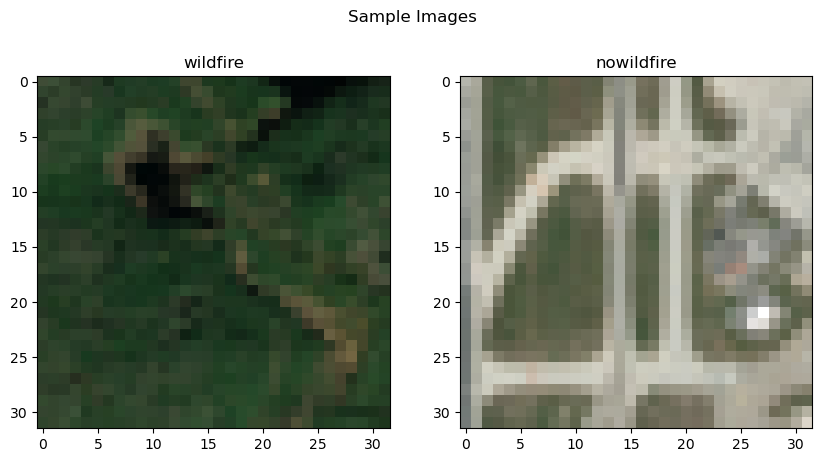

In [85]:
# displaying sample images of wildfire present and no wildfire present
fig, axes = plt.subplots(1, 2, figsize=(10, 5))

for i, cls in enumerate(classification):
    cls_path = os.path.join(data_directory, "train", cls)
    sample_file = os.listdir(cls_path)[0]
    img = Image.open(os.path.join(cls_path, sample_file)).convert("RGB")
    img = img.resize(image_dimension)
    
    axes[i].imshow(img)
    axes[i].set_title(cls)

plt.suptitle("Sample Images")
plt.show()

In [86]:
# creating directory splits for train, test, and valid samples 
X_train, y_train = load_images(os.path.join(data_directory, "train"), image_dimension, classification)
X_val,   y_val   = load_images(os.path.join(data_directory, "valid"), image_dimension, classification)
X_test,  y_test  = load_images(os.path.join(data_directory, "test"),  image_dimension, classification)

In [87]:
# Checking array dimensions
print("Checking Shapes:")
print(f"Train - {X_train.shape}")
print(f"Val - {X_val.shape}")
print(f"Test - {X_test.shape}")

Checking Shapes:
Train - (30250, 3072)
Val - (6300, 3072)
Test - (6300, 3072)


In [88]:
# Normalizing pixel data as MLP is sensitive to feature scale
mean = X_train.mean()

# preventing division by zero
std  = X_train.std() + 1e-8

# Z-score calculation
X_train = (X_train - mean) / std
X_val   = (X_val - mean) / std
X_test  = (X_test - mean) / std

In [89]:
'''
WORK IN PROGRESS BELOW... includes, past work template
'''
# adding additional libraries
import matplotlib.pyplot as plt
np.random.seed(8)

# activation functions
# https://www.geeksforgeeks.org/machine-learning/activation-functions-neural-networks/
def relu(z):
    return np.maximum(0, z)

def relu_deriv(z):
    return (z > 0).astype(np.float32)

# clipping to introduce stability when the model gets trained
def sigmoid(z):
    z = np.clip(z, -50, 50)
    return 1.0 / (1.0 + np.exp(-z))

# helper functions below to evaluate model performance
def log_loss(y_true, p, eps=1e-12):
    p = np.clip(p, eps, 1 - eps)
    return -np.mean(y_true * np.log(p) + (1 - y_true) * np.log(1 - p))

# binary classification accuracy score 
def accuracy_score(y_true, p):
    yhat = (p >= 0.5).astype(int)
    return np.mean(yhat == y_true)

In [ ]:
# step size
# accommodates the higher dimensionality of image data
eta = 0.003

# max iterations
epochs = 50

# hidden layer nodes
h = 32

# batch processing 
batch_size = 128

n_train, d = X_train.shape

# initializing weights
W1 = np.random.randn(d, h).astype(np.float32) * np.sqrt(2.0 / d)
b1 = np.zeros((1, h), dtype=np.float32)

W2 = np.random.randn(h, 1).astype(np.float32) * np.sqrt(2.0 / h)
b2 = np.zeros((1, 1), dtype=np.float32)

# storing accuracy and loss data
train_losses = []
val_losses = []
train_accs = []
val_accs = []

'''
# objective function
def f(x):
    # hidden layer
    z1 = W1.T @ x
    h = relu(z1)

    # output layer
    z2 = (w2.T @ h)[0, 0]
    return sigmoid(z2)

# binary classification (Front=0, Rear=1)
# binary cross-entropy (log loss); clip p to avoid log(0)
def log_loss(y_true, p, eps=1e-12):
    p = np.clip(p, eps, 1 - eps)
    return -np.mean(y_true * np.log(p) + (1 - y_true) * np.log(1 - p))

# performing batch gradient descent (accumulate gradients over all samples each epoch)
errors = []

for epoch in range(epochs):
    # accumulate gradients over the samples
    d_w2 = np.zeros_like(w2)
    d_W1 = np.zeros_like(W1)

    # loop through training data
    for i in range(n_train):
        x = X_train[i].reshape(d, 1)
        yi = y_train[i]

        # forward pass
        z1 = W1.T @ x
        h = relu(z1)

        # apply sigmoid sigmoid function for binary classifier
        pi = sigmoid((w2.T @ h)[0, 0])

        # error term
        error = (pi - yi)

        # gradient for w2
        d_w2 += (1/n_train) * error * h

        # ReLU application
        mask = (z1 > 0).astype(float)

        # gradient for W1
        d_W1 += (1/n_train) * error * (x @ (w2 * mask).T)

    # updating weights
    w2 = w2 - eta * d_w2
    W1 = W1 - eta * d_W1

    # compute training log loss 
    p_train = np.array([f(X_train[i].reshape(d, 1)) for i in range(n_train)])
    e = log_loss(y_train, p_train)
    errors.append(e)
    
print("W^(1):", W1)
print("w^(2):", w2)

# performing test set prediction
n_test = X_test.shape[0]
p_test = np.array([f(X_test[i].reshape(d, 1)) for i in range(n_test)])
yhat = (p_test >= 0.5).astype(int)

accuracy = np.mean(yhat == y_test)
print("Test accuracy:", accuracy)

# plotting loss / error over gradient descent
plt.plot(range(epochs), errors)
plt.title("Training log loss over GD")
plt.xlabel("epochs")
plt.ylabel("log loss")
plt.show()

# personal sanity check
np.mean(y_train), np.mean(y_test)
'''

# training loop 
# 1 hidden layer neural network with mini-batch GD

'''
Methodology:
- randomize dataset ordering
- splitting data into batches
- perform forward and backward pass on each batch
- updating weights with gradient descent
- evaluating performance on test AND validation sets
'''

for epoch in range(epochs):
    # randomize ordering
    indices = np.random.permutation(n_train)
    X_train_rand = X_train[indices]
    y_train_rand = y_train[indices]
    
    # putting training data into batches
    for start in range(0, n_train, batch_size):
        end = start + batch_size
        Xb = X_train_rand[start:end]
        yb = y_train_rand[start:end]

        # forward pass operation
        z1 = Xb @ W1 + b1
        a1 = relu(z1)
        
        # output layer
        z2 = a1 @ W2 + b2
        p  = sigmoid(z2)

        # backward pass operation
        m = Xb.shape[0]
        
        # output layer 
        dz2 = (p - yb) / m
        dW2 = a1.T @ dz2
        db2 = np.sum(dz2, axis=0, keepdims=True)
        
        # relu backprop 
        dz1 = (dz2 @ W2.T) * relu_deriv(z1)
        dW1 = Xb.T @ dz1
        db1 = np.sum(dz1, axis=0, keepdims=True)

        # updating parameter 
        # gradient descent 
        W2 -= eta * dW2
        b2 -= eta * db2
        W1 -= eta * dW1
        b1 -= eta * db1

    # epoch metrics
    
    # generating predictions on training and validation sets
    train_p = sigmoid(relu(X_train @ W1 + b1) @ W2 + b2)
    val_p = sigmoid(relu(X_val @ W1 + b1) @ W2 + b2)
    
    # finding training and validation losses
    train_loss = log_loss(y_train, train_p)
    val_loss = log_loss(y_val, val_p)
    
    # computing training and validation accuracies
    train_acc = accuracy_score(y_train, train_p)
    val_acc = accuracy_score(y_val, val_p)
    
    # store all computation data
    train_losses.append(train_loss)
    val_losses.append(val_loss)
    train_accs.append(train_acc)
    val_accs.append(val_acc)
    
    # printing results over all epochs
    print(f"Epoch {epoch+1}/{epochs}, "
          f"Train Loss: {train_loss:.4f}, "
          f"Val Loss: {val_loss:.4f}, "
          f"Train Acc: {train_acc:.4f}, "
          f"Val Acc: {val_acc:.4f}")

Epoch 1/50, Train Loss: 0.3229, Val Loss: 0.3026, Train Acc: 0.8643, Val Acc: 0.8786
Epoch 2/50, Train Loss: 0.3062, Val Loss: 0.2891, Train Acc: 0.8737, Val Acc: 0.8871
Epoch 3/50, Train Loss: 0.2964, Val Loss: 0.2788, Train Acc: 0.8767, Val Acc: 0.8881
Epoch 4/50, Train Loss: 0.2899, Val Loss: 0.2734, Train Acc: 0.8791, Val Acc: 0.8894
Epoch 5/50, Train Loss: 0.2858, Val Loss: 0.2734, Train Acc: 0.8823, Val Acc: 0.8895
Epoch 6/50, Train Loss: 0.2809, Val Loss: 0.2681, Train Acc: 0.8836, Val Acc: 0.8922
Epoch 7/50, Train Loss: 0.2782, Val Loss: 0.2666, Train Acc: 0.8862, Val Acc: 0.8916
Epoch 8/50, Train Loss: 0.2737, Val Loss: 0.2614, Train Acc: 0.8865, Val Acc: 0.8932
Epoch 9/50, Train Loss: 0.2718, Val Loss: 0.2595, Train Acc: 0.8872, Val Acc: 0.8937
Epoch 10/50, Train Loss: 0.2677, Val Loss: 0.2578, Train Acc: 0.8899, Val Acc: 0.8952
Epoch 11/50, Train Loss: 0.2655, Val Loss: 0.2564, Train Acc: 0.8913, Val Acc: 0.8944
Epoch 12/50, Train Loss: 0.2627, Val Loss: 0.2545, Train Acc: 0

In [74]:
# predicted probabilities on test set 
# binary classification

'''
https://www.geeksforgeeks.org/machine-learning/activation-functions-neural-networks/
'''
test_prob = sigmoid(relu(X_test @ W1 + b1) @ W2 + b2)

# computing accuracy and loss on test set
test_accuracy = accuracy_score(y_test, test_prob)
test_loss = log_loss(y_test, test_prob)

print("Final Test Loss:", round(float(test_loss), 4))
print("Final Test Accuracy:", round(float(test_accuracy), 4))

Final Test Loss: inf
Final Test Accuracy: 0.8762


/var/folders/kp/2zswm7155wv960mykwcg3cw80000gn/T/ipykernel_47703/4049960915.py:23: RuntimeWarning: divide by zero encountered in log
  return -np.mean(y_true * np.log(p) + (1 - y_true) * np.log(1 - p))


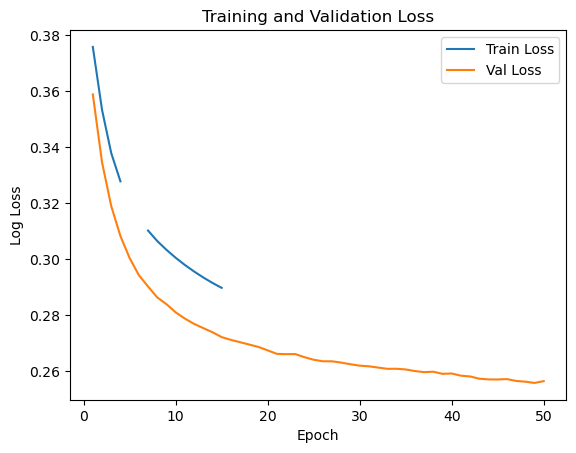

In [26]:
plt.plot(range(1, epochs + 1), train_losses, label="Train Loss")
plt.plot(range(1, epochs + 1), val_losses, label="Val Loss")
plt.xlabel("Epoch")
plt.ylabel("Log Loss")
plt.title("Training and Validation Loss")
plt.legend()
plt.show(

In [ ]:
plt.plot(range(1, epochs + 1), train_accs, label="Train Accs")
plt.plot(range(1, epochs + 1), val_accs, label="Val Accs")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training and Validation Accuracy")
plt.legend()
plt.show()

In [ ]:
# evaluating model performance further with confusion matrix and classification report

from sklearn.metrics import classification_report, confusion_matrix

# generating predictions from probabilities above
y_pred = (test_p >= 0.5).astype(int)

In [ ]:
print("Classification Report:")
print(classification_report(y_test, y_pred))

In [ ]:
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))